A place to try using the model and understand what's going on (starting at 2026-09-06)

In [1]:
import numpy as np
import pandas as pd
import streamflow_model as S

# 1) load the released (bugged) model and build standardized inputs + target
# train.csv holds the weather/soil inputs AND the observed streamflow; this helper
# builds the 72-hour windowed, z-scored inputs and the aligned target for you
weights = S.load_weights("model/streamflow_model_bug.npz")
feats = S.build_features("data/train.csv", "model/feature_scaler.json")
X, truth = feats["X"], feats["truth"]
print(f"{len(X)} usable examples, {X.shape[1]} features each")

18685 usable examples, 77 features each


In [2]:
weights


{'fc1.weight': array([[-7.6256139e-04, -2.3746791e-03, -8.8769691e-03, ...,
          8.5218757e-02, -1.6181801e-02,  7.2891386e-03],
        [-3.1426749e-03,  7.9153047e-04, -3.6873659e-03, ...,
          1.3013140e-03, -5.1770508e-03, -2.3167159e-03],
        [ 2.4503397e-03, -4.7176899e-03, -2.0749883e-03, ...,
          8.7047644e-02, -1.8316310e-02,  9.1621485e-03],
        ...,
        [ 6.6765735e-04,  7.9982396e-04,  4.5840577e-03, ...,
         -1.2756642e-03, -1.2584943e-02, -8.9259371e-03],
        [ 6.2570921e-03,  3.9026842e-03, -6.4627454e-03, ...,
          8.7492988e-02, -2.6787795e-02,  2.8941799e-05],
        [ 9.4705191e-04,  2.8219615e-04,  1.1736418e-03, ...,
          1.3278663e-05, -1.3123732e-03,  1.0234135e-04]],
       shape=(56, 77), dtype=float32),
 'fc1.bias': array([ 9.7290548e-03, -6.1009484e-03,  1.3537866e-02,  3.5892490e-02,
         3.6433190e-02, -1.6346129e-02, -1.9985953e-02,  9.6243730e-06,
        -1.9834816e-02, -1.1506662e-04, -9.7885248e-05, -

In [3]:
# for name, arr in acts.items():
#     print(name, arr.shape)

In [4]:
feats
# truth: truth streamflow value of each training data


{'X': array([[ 4.2192993 ,  2.7683449 ,  0.96176416, ..., -0.51768625,
         -0.5767691 , -0.65030074],
        [ 2.7683449 ,  0.96176416,  0.606138  , ..., -0.5185916 ,
         -0.58524597, -0.65030074],
        [ 0.96176416,  0.606138  ,  0.23628683, ..., -0.51949656,
         -0.6021998 , -0.64080656],
        ...,
        [-0.11933929, -0.11933929, -0.11933929, ..., -1.2302608 ,
         -1.0090902 ,  0.16334933],
        [-0.11933929, -0.11933929, -0.11933929, ..., -1.2305154 ,
         -0.81412184,  0.338042  ],
        [-0.11933929, -0.11933929, -0.11933929, ..., -1.2307692 ,
         -0.6021998 ,  0.9195598 ]], shape=(18685, 77), dtype=float32),
 'row_id': array([    0,     1,     2, ..., 18682, 18683, 18684], shape=(18685,)),
 'datetime': array(['2023-10-29T11:00:00.000000', '2023-10-29T12:00:00.000000',
        '2023-10-29T13:00:00.000000', ..., '2025-12-16T16:00:00.000000',
        '2025-12-16T17:00:00.000000', '2025-12-16T18:00:00.000000'],
       shape=(18685,), dtype=

In [5]:
train = pd.read_csv("data/train.csv")

In [6]:
train

,datetime,rain_mm,T_air_C,RH_pct,srad_Wm2,Tsoil_4in_C,sm_2in,sm_20in,season,streamflow_mm_hr
0,2023-10-26 12:00:00,3.05,13.1,98.0,42.3,11.6,0.10,0.07,0.287149,0.034445
1,2023-10-26 13:00:00,2.03,13.3,98.0,42.3,11.6,0.10,0.07,0.286825,0.033318
2,2023-10-26 14:00:00,0.76,13.6,98.0,42.3,11.6,0.10,0.07,0.286501,0.031673
3,2023-10-26 15:00:00,0.51,14.4,98.2,42.3,11.6,0.10,0.07,0.286177,0.032089
4,2023-10-26 16:00:00,0.25,15.5,98.2,42.3,11.6,0.10,0.07,0.285853,0.032229
...,...,...,...,...,...,...,...,...,...,...
18751,2025-12-16 14:00:00,0.00,-8.9,84.1,10.2,0.7,0.06,0.06,0.015830,0.000410
18752,2025-12-16 15:00:00,0.00,-7.5,82.9,85.2,0.7,0.06,0.06,0.015741,0.000409
18753,2025-12-16 16:00:00,0.00,-5.1,79.4,171.4,0.7,0.06,0.06,0.015651,0.000407
18754,2025-12-16 17:00:00,0.00,-2.8,75.3,208.2,0.7,0.06,0.06,0.015563,0.000405


In [7]:
#check how does the feature_scalar.json is generated
last_var = train["srad_Wm2"][71:] #returns series

In [8]:
last_var.mean()

np.float64(141.7237195611437)

In [9]:
# 2) run the model, and grab hidden activations (for your analysis)
pred, acts = S.forward(weights, X, return_hidden=True)
print("layers with activations:", list(acts.keys()))

layers with activations: ['fc1', 'fc2', 'fc3', 'fc4', 'fc5', 'fc6']


In [10]:
W, b = weights["fc1.weight"], weights["fc1.bias"]
x = X[0]                              # one hour, shape (77,)
manual = np.maximum(0, W @ x + b)     # (56,77) @ (77,) -> (56,)
print(np.allclose(manual, acts["fc1"][0]))

True


In [11]:
a = acts["fc1"]
print((a == 0).mean())                 # fraction of all entries that are silent
print((a > 0).mean(axis=0).round(2))   # per-neuron: fraction of hours it fires

0.554023471845254
[0.49 0.22 0.49 0.72 0.55 0.22 0.16 0.64 0.18 0.15 0.42 0.15 0.52 0.16
 0.72 0.48 0.18 0.25 0.7  0.16 0.19 0.69 0.52 0.61 0.52 0.51 0.26 0.52
 0.19 0.6  0.51 0.16 0.51 0.7  0.66 0.65 0.17 0.22 0.69 0.16 0.58 0.48
 0.64 0.57 0.64 0.71 0.64 0.4  0.64 0.51 0.58 0.57 0.59 0.2  0.46 0.19]


In [12]:
pred

array([0.03030184, 0.0260518 , 0.0219172 , ..., 0.00782154, 0.00782154,
       0.00782154], shape=(18685,), dtype=float32)

In [13]:
acts

{'fc1': array([[0.        , 0.        , 0.        , ..., 0.        , 0.02310764,
         0.00650362],
        [0.        , 0.        , 0.00367412, ..., 0.        , 0.01878087,
         0.00363632],
        [0.00126431, 0.        , 0.00669809, ..., 0.        , 0.00516277,
         0.00167874],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(18685, 56), dtype=float32),
 'fc2': array([[1.75683947e-11, 8.33997888e-07, 4.83879149e-02, ...,
         3.13184228e-06, 5.62207364e-02, 4.84320917e-05],
        [1.45264955e-11, 9.53904191e-07, 3.91136855e-02, ...,
         2.60677825e-06, 4.54209596e-02, 4.95984677e-05],
        [1.18582861e-11, 1.09279313e-06, 3.04938070e-02, ...,
         2.03416607e-06, 3.52958702e-02, 5.07397781e-05],
 

In [14]:
# 3) basic statistics
print("\nprediction stats (mm/hr):")
print(f"mean {pred.mean():.4f} std {pred.std():.4f}"
      f"min {pred.min():.4f} max {pred.max():.4f}")
print(f"skill vs observed: NSE {S.nse(pred, truth):.3f} RMSE {S.rmse(pred, truth):.4f}")


prediction stats (mm/hr):
mean 0.0265 std 0.0264min 0.0078 max 0.5884
skill vs observed: NSE 0.679 RMSE 0.0169


### score how close the predictions are to the observed streamflow

**RMSE, root mean squared error**

`RMSE = sqrt( mean( (pred − truth)² ) )`

Take every hour's error, square it, average, take the square root. It's in the same units as the target, mm/hr, so it answers "how far off is a typical prediction?" Lower is better and 0 is perfect. Squaring means big misses, like getting a flood peak wrong, dominate the score.

here in our case unit: mm/hr

**NSE, Nash–Sutcliffe efficiency**

`NSE = 1 − sum((pred − truth)²) / sum((truth − mean(truth))²)`

This is the hydrology community's standard skill score. The numerator is your model's squared error. The denominator is the squared error you'd get from the dumbest possible model, one that predicts the average streamflow for every hour. So NSE compares you against that baseline:

| NSE | Meaning |
|---|---|
| 1.0 | perfect |
| 0.66 | your errors are 34% of the "predict the mean" errors |
| 0.0 | no better than predicting the mean |
| negative | worse than predicting the mean |

Higher is better. If you know R² from statistics, NSE is the same formula.

In [15]:
# peek at an example weight matrix
print(f"\nfc3.weight: shape {weights['fc3.weight'].shape}")
print(np.round(weights["fc3.weight"][:3, :6], 3)) # change these to see diff values



fc3.weight: shape (56, 56)
[[ 0.    -0.     0.008  0.007  0.008  0.007]
 [-0.    -0.     0.022  0.019  0.023  0.015]
 [ 0.    -0.     0.021  0.017  0.021  0.014]]


In [16]:
# 4) write a (placeholder) submission -> submission.csv  (this is what you upload)
#    feature_direction : (56,)  your recovered leak direction
#    fc_weight_corrected : (56,56) your repaired weight matrix for the affected layer
# (placeholders below score ~0; swap in your recovered direction and repaired matrix)
feature_direction = np.zeros(56, np.float32)             # REPLACE ME
fc_weight_corrected = np.zeros((56, 56), np.float32)     # REPLACE ME


In [17]:
X.shape #numpy shape read outer axis first

(18685, 77)

# Do some SHAP

In [18]:
#just write my version for now. referencing what michal did in 09/09/2026
import shap as shp
f = lambda x: S.forward(weights, x)
background = shp.kmeans(X, 100).data #just use 100 values from the training data, insead of doing the all 18k
explainer = shp.KernelExplainer(f, background) #store the function and background

In [19]:
sample = X[:500]
shap_values = explainer.shap_values(sample)

  0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [20]:
#make a feature name table, 72 rainfall logs + 5 features
feature_names = [f"rain_t-{71-i}" for i in range(72)] #-71 is the oldest, -0 is the most recent, which is the current hour
# for i in range(72):
#     feature_names.append()
print(feature_names)

feature_names.extend(['sm_2in', 'sm_20in', 'season', 'T_air_C', 'srad_Wm2'])
print(feature_names)
michal_names = ['rain_t-71', 'rain_t-70', 'rain_t-69', 'rain_t-68', 'rain_t-67', 'rain_t-66', 'rain_t-65', 'rain_t-64', 'rain_t-63', 'rain_t-62', 'rain_t-61', 'rain_t-60', 'rain_t-59', 'rain_t-58', 'rain_t-57', 'rain_t-56', 'rain_t-55', 'rain_t-54', 'rain_t-53', 'rain_t-52', 'rain_t-51', 'rain_t-50', 'rain_t-49', 'rain_t-48', 'rain_t-47', 'rain_t-46', 'rain_t-45', 'rain_t-44', 'rain_t-43', 'rain_t-42', 'rain_t-41', 'rain_t-40', 'rain_t-39', 'rain_t-38', 'rain_t-37', 'rain_t-36', 'rain_t-35', 'rain_t-34', 'rain_t-33', 'rain_t-32', 'rain_t-31', 'rain_t-30', 'rain_t-29', 'rain_t-28', 'rain_t-27', 'rain_t-26', 'rain_t-25', 'rain_t-24', 'rain_t-23', 'rain_t-22', 'rain_t-21', 'rain_t-20', 'rain_t-19', 'rain_t-18', 'rain_t-17', 'rain_t-16', 'rain_t-15', 'rain_t-14', 'rain_t-13', 'rain_t-12', 'rain_t-11', 'rain_t-10', 'rain_t-9', 'rain_t-8', 'rain_t-7', 'rain_t-6', 'rain_t-5', 'rain_t-4', 'rain_t-3', 'rain_t-2', 'rain_t-1', 'rain_t-0', 'sm_2in', 'sm_20in', 'season', 'T_air_C', 'srad_Wm2']
print(michal_names == feature_names) #True

['rain_t-71', 'rain_t-70', 'rain_t-69', 'rain_t-68', 'rain_t-67', 'rain_t-66', 'rain_t-65', 'rain_t-64', 'rain_t-63', 'rain_t-62', 'rain_t-61', 'rain_t-60', 'rain_t-59', 'rain_t-58', 'rain_t-57', 'rain_t-56', 'rain_t-55', 'rain_t-54', 'rain_t-53', 'rain_t-52', 'rain_t-51', 'rain_t-50', 'rain_t-49', 'rain_t-48', 'rain_t-47', 'rain_t-46', 'rain_t-45', 'rain_t-44', 'rain_t-43', 'rain_t-42', 'rain_t-41', 'rain_t-40', 'rain_t-39', 'rain_t-38', 'rain_t-37', 'rain_t-36', 'rain_t-35', 'rain_t-34', 'rain_t-33', 'rain_t-32', 'rain_t-31', 'rain_t-30', 'rain_t-29', 'rain_t-28', 'rain_t-27', 'rain_t-26', 'rain_t-25', 'rain_t-24', 'rain_t-23', 'rain_t-22', 'rain_t-21', 'rain_t-20', 'rain_t-19', 'rain_t-18', 'rain_t-17', 'rain_t-16', 'rain_t-15', 'rain_t-14', 'rain_t-13', 'rain_t-12', 'rain_t-11', 'rain_t-10', 'rain_t-9', 'rain_t-8', 'rain_t-7', 'rain_t-6', 'rain_t-5', 'rain_t-4', 'rain_t-3', 'rain_t-2', 'rain_t-1', 'rain_t-0']
['rain_t-71', 'rain_t-70', 'rain_t-69', 'rain_t-68', 'rain_t-67', 'rain_t

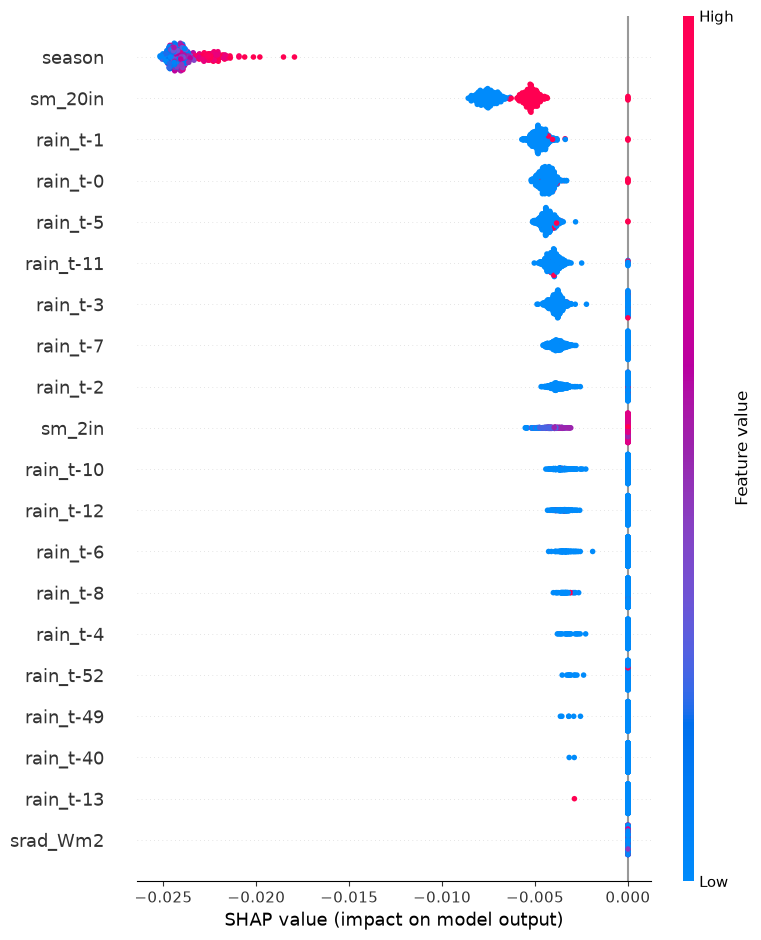

In [40]:
shp.summary_plot(shap_values, sample, feature_names=feature_names, max_display=20)

In [43]:
# I want to do every 2 months, which probably I can do every 60 days * 24 hrs = 1440 hours. Or I can do a divide so can divide evenly, anyway
18685 % 1440

1405

In [21]:
import math
itrs = 18685 / 1440 # 12.95 something, so will make 13 chops
chopped = []
for i in range(math.ceil(itrs)): #should be 13, so 0-12 iterations
    
    if i == math.ceil(itrs) - 1: #should be 12
        chopped.append(X[(i)*1440:]) #last one is not full 1440, so just take the rest
    else:
        chopped.append(X[i*1440:(i+1)*1440])
print(len(chopped))
print(chopped) #divided into 13 chunks, first 12 are 1440, last one is 1405; saved in a list, 
# np.array(chopped).shape

13
[array([[ 4.2192993 ,  2.7683449 ,  0.96176416, ..., -0.51768625,
        -0.5767691 , -0.65030074],
       [ 2.7683449 ,  0.96176416,  0.606138  , ..., -0.5185916 ,
        -0.58524597, -0.65030074],
       [ 0.96176416,  0.606138  ,  0.23628683, ..., -0.51949656,
        -0.6021998 , -0.64080656],
       ...,
       [-0.11933929, -0.11933929, -0.11933929, ..., -1.2733938 ,
        -0.6445842 , -0.65030074],
       [-0.11933929, -0.11933929, -0.11933929, ..., -1.2734433 ,
        -0.6191535 , -0.65030074],
       [-0.11933929, -0.11933929, -0.11933929, ..., -1.2734922 ,
        -0.58524597, -0.65030074]], shape=(1440, 77), dtype=float32), array([[-0.11933929, -0.11933929, -0.11933929, ..., -1.2735405 ,
        -0.5682922 , -0.65030074],
       [-0.11933929, -0.11933929, -0.11933929, ..., -1.273588  ,
        -0.55981535, -0.65030074],
       [-0.11933929, -0.11933929, -0.11933929, ..., -1.2736347 ,
        -0.55981535, -0.65030074],
       ...,
       [-0.11933929, -0.11933929, -0.

In [ ]:
# import matplotlib.pyplot as plt
# for i in range(len(chopped)):
#     chunk = chopped[i]
#     shap_values = explainer.shap_values(chunk)
#     shp.summary_plot(shap_values, chunk, feature_names=feature_names, max_display=20, show=False)
#     plt.savefig("./figures/chunk_{}.png".format(i), dpi=200, bbox_inches="tight")
#     plt.close()


(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1440, 77)
(1405, 77)


## SHAP with DeepExplainer (added by Claude, 2026-09-10)

Same 2-month chunks as above, but using `DeepExplainer`, which reads gradients from a PyTorch copy of the model instead of probing it thousands of times. Whole loop should take a couple of minutes instead of hours. Reuses `chopped`, `background`, `feature_names` from the cells above.

In [22]:
# 1) Build a PyTorch copy of the model from the same weights (recipe from the bottom of starter.py).
#    Each nn.Linear is one "h @ W.T + b"; nn.ReLU after every layer except the output.
import torch, torch.nn as nn

layer_names = ["fc1", "fc2", "fc3", "fc4", "fc5", "fc6", "out"]
dims = [77, 56, 56, 56, 56, 56, 56, 1]
mods = []
for i, name in enumerate(layer_names):
    lin = nn.Linear(dims[i], dims[i + 1])
    lin.weight.data = torch.tensor(weights[f"{name}.weight"])
    lin.bias.data = torch.tensor(weights[f"{name}.bias"])
    mods.append(lin)
    if name != "out":
        mods.append(nn.ReLU())
net = nn.Sequential(*mods).eval()

# sanity check: the torch model must give the same predictions as S.forward
pred_torch = net(torch.tensor(X)).squeeze(-1).detach().numpy()
print("torch model matches numpy forward:", np.allclose(pred_torch, pred, atol=1e-5))

torch model matches numpy forward: True


In [23]:
# 2) DeepExplainer needs tensors. Same 100 k-means background rows as the kernel run, so results are comparable.
background_tensor = torch.tensor(background, dtype=torch.float32)
deep_explainer = shp.DeepExplainer(net, background_tensor)

In [24]:
# 3) Same 2-month chunk loop as above, with DeepExplainer. Title carries the date range so the 13 files are tellable apart.
import matplotlib.pyplot as plt
dates = feats["datetime"]   # lines up with X row for row

for i, chunk in enumerate(chopped):
    start = i * 1440
    end = start + len(chunk)

    sv = deep_explainer.shap_values(torch.tensor(chunk, dtype=torch.float32))
    sv = np.squeeze(sv, axis=-1)          # (N, 77, 1) -> (N, 77): one output, so drop the last axis

    shp.summary_plot(sv, chunk, feature_names=feature_names, max_display=20, show=False)
    d0, d1 = np.datetime_as_string(dates[start], unit="D"), np.datetime_as_string(dates[end - 1], unit="D")
    plt.title(f"chunk {i}: {d0} to {d1}  (n={len(chunk)})")
    plt.savefig(f"./figures/chunk_{i}_deep.png", dpi=200, bbox_inches="tight")
    plt.close()
    print(f"chunk {i} done: {d0} to {d1}")

chunk 0 done: 2023-10-29 to 2023-12-28
chunk 1 done: 2023-12-28 to 2024-02-26
chunk 2 done: 2024-02-26 to 2024-04-26
chunk 3 done: 2024-04-26 to 2024-06-25
chunk 4 done: 2024-06-25 to 2024-08-24
chunk 5 done: 2024-08-24 to 2024-10-23


KeyboardInterrupt: 

In [26]:
#do all 77 features show up

for i, chunk in enumerate(chopped):
    start = i * 1440
    end = start + len(chunk)

    sv = deep_explainer.shap_values(torch.tensor(chunk, dtype=torch.float32))
    sv = np.squeeze(sv, axis=-1)          # (N, 77, 1) -> (N, 77): one output, so drop the last axis

    shp.summary_plot(sv, chunk, feature_names=feature_names, max_display=77, show=False, plot_size=(10, 22))
    ax = plt.gca()
    names = [t.get_text() for t in ax.get_yticklabels()]
    n = len(names)
    mean_abs = dict(zip(feature_names, np.abs(sv).mean(axis=0)))   # this chunk's mean |SHAP| per feature, by name
    ax.set_yticks(np.arange(n), [f"{n - k:>2}  {name:<9} {mean_abs[name]:.5f}" for k, name in enumerate(names)],
                  fontsize=7, family="monospace")                   # monospace so the three columns line up
    for r in range(10, n, 10):
        ax.axhline(n - r - 0.5, color="grey", lw=0.5, ls="--")
    d0, d1 = np.datetime_as_string(dates[start], unit="D"), np.datetime_as_string(dates[end - 1], unit="D")
    plt.title(f"chunk {i}: {d0} to {d1}  (n={len(chunk)})")
    plt.savefig(f"./figures/all_feats/chunk_{i}_deep.png", dpi=200, bbox_inches="tight")
    plt.close()
    print(f"chunk {i} done: {d0} to {d1}")

chunk 0 done: 2023-10-29 to 2023-12-28
chunk 1 done: 2023-12-28 to 2024-02-26
chunk 2 done: 2024-02-26 to 2024-04-26
chunk 3 done: 2024-04-26 to 2024-06-25
chunk 4 done: 2024-06-25 to 2024-08-24
chunk 5 done: 2024-08-24 to 2024-10-23
chunk 6 done: 2024-10-23 to 2024-12-22
chunk 7 done: 2024-12-22 to 2025-02-20
chunk 8 done: 2025-02-20 to 2025-04-21
chunk 9 done: 2025-04-21 to 2025-06-20
chunk 10 done: 2025-06-20 to 2025-08-19
chunk 11 done: 2025-08-19 to 2025-10-18
chunk 12 done: 2025-10-18 to 2025-12-16


## Mean |SHAP| per rain lag: the lag curve (added by Claude, 2026-09-23)

One number per rain lag: the average size of its SHAP value over all 18,685 hours. Plotted against hours-ago, this shows the *shape* of the model's memory of rain, which the ranked beeswarms can't: rank hides size, and the beeswarm rows aren't in time order.

- Physical expectation: high at lag 0, fading smoothly with age.
- Reuses `chopped`, `deep_explainer`, `feature_names`, `pred` from the cells above.
- The first cell computes SHAP for every hour once and caches it in `cache/` (about 2 min). Re-run the plot cells freely after that.

In [ ]:
# 4) SHAP for every hour, computed once and cached. The figure cells below only read `all_sv`.
import os
os.makedirs("cache", exist_ok=True)
cache_path = "cache/shap_values_deep.npy"   # 18685 x 77 float32, ~5.7 MB. Safe to gitignore.

if os.path.exists(cache_path):
    all_sv = np.load(cache_path)
    print("loaded cached SHAP values:", all_sv.shape)
else:
    sv_list = []
    for i, chunk in enumerate(chopped):
        sv = deep_explainer.shap_values(torch.tensor(chunk, dtype=torch.float32))
        sv_list.append(np.squeeze(sv, axis=-1))       # (N, 77, 1) -> (N, 77)
        print(f"chunk {i} done")
    all_sv = np.concatenate(sv_list, axis=0)          # (18685, 77), same row order as X
    np.save(cache_path, all_sv)
    print("computed and cached:", all_sv.shape)

# per-chunk slices of the pooled array (no recompute), used for the faint background lines
bounds = np.cumsum([0] + [len(c) for c in chopped])
sv_list = [all_sv[bounds[i]:bounds[i + 1]] for i in range(len(chopped))]

In [ ]:
# 5) The numbers behind the curve
imp = np.abs(all_sv).mean(axis=0)        # 77 numbers: mean |SHAP| per feature
lag_imp = imp[:72][::-1]                 # column 0 is rain_t-71, so reverse: index = hours ago
lags = np.arange(72)

print("block means   0-13: %.5f   14-38: %.5f   39-71: %.5f" % (lag_imp[:14].mean(), lag_imp[14:39].mean(), lag_imp[39:].mean()))
order = np.argsort(lag_imp)[::-1]
print("top 15 rain lags:", ", ".join(f"t-{l} {lag_imp[l]:.5f}" for l in order[:15]))
print("bottom 10:       ", ", ".join(f"t-{l} {lag_imp[l]:.5f}" for l in order[-10:]))
print("statics:         ", ", ".join(f"{n} {v:.5f}" for n, v in zip(feature_names[72:], imp[72:])))

In [ ]:
# 6) The lag curve: pooled (bold) plus each 60-day chunk (faint), log y
chunk_imp = [np.abs(sv).mean(axis=0)[:72][::-1] for sv in sv_list]

fig, ax = plt.subplots(figsize=(11, 4.5))
for c in chunk_imp:
    ax.plot(lags, c, color="grey", lw=0.6, alpha=0.4)
ax.plot(lags, lag_imp, color="C0", lw=2, marker="o", ms=3, label="all 18,685 hours")
ax.plot([], [], color="grey", lw=0.6, alpha=0.6, label="each 60-day chunk")   # legend entry only
for lag in (9, 40, 49, 52):                                                    # the lags the beeswarms flagged
    ax.annotate(f"t-{lag}", (lag, lag_imp[lag]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color="C3")

ax.set_yscale("log")                     # lag 0-1 would flatten everything else on a linear axis
ax.set_xlabel("hours ago (rain lag)")
ax.set_ylabel("mean |SHAP| (mm/hr)")
ax.set_xticks(range(0, 72, 6))
ax.grid(True, which="both", alpha=0.3)
ax.legend()
ax.set_title("How much the model relies on rain from each hour back")
plt.savefig("figures/shap_lag_curve.png", dpi=200, bbox_inches="tight")